# **Lab 02:** Creating your own CNN with PyTorch

### **General Instructions**

- In this lab, you'll create your own CNN in order to surpass an accuracy of 70% on CIFAR-10.

### **System Diagram Requirement**

You must include a **diagram of your system pipeline** showing the CNN architecture.

This diagram is **required** to understand your model logic.

You can draw it digitally, use any Pyhton library, or by hand and include an image.

If your diagram was created assisted by GenAI, also include the `promt` used in the next block. If the generated system diagram is not clear or you cannot interpret it, adjust the prompt as needed or draw it by hand.

*If you used GenAI, write your prompt here..*

### **Load the CIFAR-10 dataset**

In [1]:
# Load the CIFAR-10 dataset here
import torch
import torchvision
import torchvision.transforms as transforms

# Transformaciones (convertir a tensor y normalizar)
transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize((0.5, 0.5, 0.5), 
                         (0.5, 0.5, 0.5))
])

# Descargar dataset de entrenamiento
trainset = torchvision.datasets.CIFAR10(
    root='./data',
    train=True,
    download=True,
    transform=transform
)

trainloader = torch.utils.data.DataLoader(
    trainset,
    batch_size=32,
    shuffle=True
)

# Dataset de prueba
testset = torchvision.datasets.CIFAR10(
    root='./data',
    train=False,
    download=True,
    transform=transform
)

testloader = torch.utils.data.DataLoader(
    testset,
    batch_size=32,
    shuffle=False
)

print(len(trainset))  # 50000
print(len(testset))   # 10000

/home/ariel/Escritorio/proyectos/Computer_Vision/.venv/lib/python3.12/site-packages/torchvision/datasets/cifar.py:83: VisibleDeprecationWarning: dtype(): align should be passed as Python or NumPy boolean but got `align=0`. Did you mean to pass a tuple to create a subarray type? (Deprecated NumPy 2.4)
  entry = pickle.load(f, encoding="latin1")


50000
10000


In [2]:
# Ver los nombres de las categorías
classes = trainset.classes
print(f"Las clases son: {classes}")

# Ver el número total de clases
num_classes = len(trainset.classes)
print(f"Número de clases: {num_classes}")

Las clases son: ['airplane', 'automobile', 'bird', 'cat', 'deer', 'dog', 'frog', 'horse', 'ship', 'truck']
Número de clases: 10


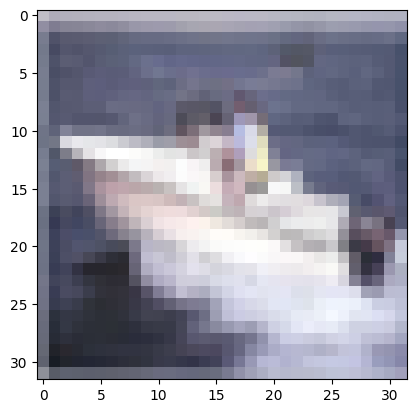

Etiqueta real: ship


In [3]:
import matplotlib.pyplot as plt
import numpy as np

# Función para mostrar una imagen
def imshow(img):
    img = img / 2 + 0.5     # Des-normalizar (operación inversa a la que hiciste arriba)
    npimg = img.numpy()
    plt.imshow(np.transpose(npimg, (1, 2, 0))) # Reordenar dimensiones
    plt.show()

# Obtener algunas imágenes aleatorias del trainloader
dataiter = iter(trainloader)
images, labels = next(dataiter)

# Mostrar la primera imagen del batch
imshow(images[0])
print(f"Etiqueta real: {classes[labels[0]]}")

### **Create your CNN with PyTorch and train it on the CIFAR-10 dataset**

In [4]:
# Create your own CNN using PyTorch and train it on the CIFAR-10 dataset
from torch import nn
import torch.nn.functional as F

class CNN(nn.Module):
    def __init__(self, num_chanels, num_classes):
        super(CNN, self).__init__()

        self.conv1 = nn.Conv2d(in_channels=num_chanels, out_channels=8, kernel_size=3, padding=1)
        self.pool = nn.MaxPool2d(kernel_size=2, stride=2)
        self.conv2 = nn.Conv2d(in_channels=8, out_channels=16, kernel_size=3, padding=1)
        self.conv3 = nn.Conv2d(in_channels=16, out_channels=32, kernel_size=3, padding=1)
        self.dropout = nn.Dropout(p=0.5)
        self.fc1 = nn.Linear(in_features=32*4*4, out_features=256)
        self.fc2 = nn.Linear(in_features=256, out_features=num_classes)
        self.bn1 = nn.BatchNorm2d(8)
        self.bn2 = nn.BatchNorm2d(16)
        self.bn3 = nn.BatchNorm2d(32)
        self.bn4 = nn.BatchNorm1d(256)

    
    def forward(self, x):
        x = self.pool(F.relu(self.bn1(self.conv1(x))))
        x = self.pool(F.relu(self.bn2(self.conv2(x))))
        x = self.pool(F.relu(self.bn3(self.conv3(x))))
        x = x.reshape(x.shape[0], -1)
        x = F.relu(self.bn4(self.fc1(x)))
        x = self.dropout(x)
        x = self.fc2(x)
        
        return x

In [5]:
from torch import optim
device = "cuda"
model = CNN(num_chanels=3, num_classes=10).to(device)
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=0.001)

In [ ]:
from tqdm import tqdm

num_epochs = 50 # 50 pueden ser muchos si no tienes GPU, prueba con 10 primero
for epoch in range(num_epochs):
    losses = []
    num_correct = 0
    num_samples = 0
    
    # Configuramos tqdm con un diseño más limpio
    loop = tqdm(enumerate(trainloader), total=len(trainloader), leave=True)
    
    for batch_idx, (data, targets) in loop:
        data = data.to(device)
        targets = targets.to(device)

        # Forward
        scores = model(data)
        loss = criterion(scores, targets)
        losses.append(loss.item())

        # Backward
        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

        # Calcular Accuracy en tiempo real
        _, predictions = scores.max(1)
        num_correct += (predictions == targets).sum()
        num_samples += predictions.size(0)
        current_acc = float(num_correct) / num_samples

        # Actualizar la barra de progreso de tqdm
        loop.set_description(f"Epoch [{epoch+1}/{num_epochs}]")
        loop.set_postfix(loss=loss.item(), acc=f"{current_acc*100:.2f}%")

    # Al final del epoch puedes imprimir el promedio
    print(f"-> Epoch {epoch+1} finalizado. Loss promedio: {sum(losses)/len(losses):.4f}")

Epoch [1/50]: 100%|██████████| 1563/1563 [00:12<00:00, 128.43it/s, acc=51.54%, loss=1.8]  


-> Epoch 1 finalizado. Loss promedio: 1.3515


Epoch [2/50]: 100%|██████████| 1563/1563 [00:11<00:00, 133.60it/s, acc=61.22%, loss=0.806]


-> Epoch 2 finalizado. Loss promedio: 1.0969


Epoch [3/50]: 100%|██████████| 1563/1563 [00:11<00:00, 134.89it/s, acc=64.89%, loss=0.735]


...

-> Epoch 48 finalizado. Loss promedio: 0.4538


Epoch [49/50]: 100%|██████████| 1563/1563 [00:11<00:00, 130.82it/s, acc=83.84%, loss=0.682]


-> Epoch 49 finalizado. Loss promedio: 0.4480


Epoch [50/50]: 100%|██████████| 1563/1563 [00:11<00:00, 131.43it/s, acc=83.62%, loss=0.538]

-> Epoch 50 finalizado. Loss promedio: 0.4506


Write here the architectural justification of the modifications...

### **Evaluate the accuracy of your CNN (must be >= 70%)**

In [7]:
# Evaluate the accuracy of your CNN (must be >= 70%)
def check_accuracy(loader, model, device):
    num_correct = 0
    num_samples = 0
    model.eval()
    
    with torch.no_grad():
        for x, y in loader:
            x = x.to(device)
            y = y.to(device)
            
            scores = model(x)
            _, predictions = scores.max(1) 
            
            num_correct += (predictions == y).sum()
            num_samples += predictions.size(0)
        
        acc = float(num_correct) / num_samples
        print(f'Test Accuracy: {acc * 100:.2f}% ({num_correct}/{num_samples})')
    
    model.train()
    return acc

check_accuracy(testloader, model, device)

Test Accuracy: 74.40% (7440/10000)


0.744

### **System Diagram**

Insert your system diagram (CNN architecture) below (image or drawing). It must clearly show:

- Number of convolutional layers  
- Kernel size(s)
- Pooling layers (if any)  
- etc..  

# Insert or display your system diagram image here
![Descripción](diagrama_cnn.png)

### **Written Analysis Questions**

**1. Why increasing depth could improve performance.**

Because let the CNN learn more complex features, which can lead to better performance on the task at hand. Deeper networks can capture more intricate patterns and relationships in the data, which can be beneficial for tasks like image classification where there are many subtle features that can be important for distinguishing between classes.

**2. Under what conditions deeper networks may hurt performance.**

In cases where the dataset has no complex patterns, deeper neural network could be more prone to overfitting, especially if the dataset is small. Additionally, deeper networks can be more difficult to train due to issues like vanishing gradients, which can lead to slower convergence and worse performance.

**3. How could dropout, batch normalization, or data augmentation help?**

Dropout can help prevent overfitting by randomly dropping out neurons during training, which forces the network to learn more robust features. Batch normalization can help stabilize and accelerate training by normalizing the inputs to each layer, which can lead to better performance. Data augmentation can help increase the diversity of the training data, which can also help prevent overfitting and improve generalization.

**4. How would you determine whether your CNN is overfitting or underfitting?**

To determine whether a CNN is overfitting or underfitting, you can analyze the training and validation loss and accuracy curves. If the training loss continues to decrease while the validation loss starts to increase, it indicates overfitting. On the other hand, if both training and validation losses are high and do not improve, it suggests underfitting. Additionally, you can evaluate the model's performance on a separate test set to further confirm whether it is overfitting or underfitting.

**5. Which architectural components most impact computational cost?**

The layers with the most parameters, such as fully connected layers, and the convolutional layers with large kernel sizes or a high number of filters, typically have the greatest impact on computational cost. Additionally, the depth of the network can also contribute to increased computational cost.

**6. Whether the accuracy gain justifies the added complexity in a real-world deployment scenario.**

Whether the accuracy gain justifies the added complexity in a real-world deployment scenario depends on the specific use case and requirements of the application. If the improved accuracy significantly enhances the user experience or provides critical functionality, it may justify the added complexity. However, if the increase in accuracy is marginal and does not provide a noticeable benefit to users, it may not be worth the additional computational resources and maintenance costs associated with a more complex model.

## **Grading Rubric (10 points)**

| Criterion | Points |
|------------|--------|
| **Baseline Reproduction** – Correct implementation and training of the provided baseline CNN. Clear report of baseline accuracy and training setup. | 1 |
| **Architectural Modifications** – Meaningful and technically justified changes to the CNN architecture (e.g., depth, kernel size, normalization, dropout, residual connections). Changes must go beyond trivial parameter tuning. | 2 |
| **Written Architectural Justification** – Clear explanation of *why* the chosen modifications should improve performance (receptive field, feature hierarchy, regularization, gradient flow, etc.). | 2 |
| **Experimental Design & Comparison** – Systematic comparison between baseline and modified model (same dataset split, controlled variables, reported metrics). Includes training/validation accuracy curves. | 2 |
| **Performance Improvement** – Modified architecture surpasses baseline validation/test accuracy. <br>• +1% improvement: 0.5 pts <br>• +2% improvement: 1 pt | 2 |
| **Computational Tradeoff Reflection** – Analysis of parameter count, training time, and whether the accuracy gain justifies the added complexity. | 1 |
| **Code Clarity & PyTorch Best Practices** – Clean modular implementation (proper use of `nn.Module`, readable forward pass, reproducibility practices). | 1 |
| **Total** | **10** |


### Presentation Rubric

| Criterion | Points |
|------------|--------|
| **Architectural Modifications** – Meaningful and technically justified changes to the CNN architecture (e.g., depth, kernel size, normalization, dropout, residual connections). Changes must go beyond trivial parameter tuning. | 2 |
| **Architectural Justification** – Clear explanation of *why* the chosen modifications should improve performance (receptive field, feature hierarchy, regularization, gradient flow, etc.). | 2 |
|**System Design** - Explanation of the architectural modifications on the diagram. | 2 |
| **Performance Improvement** – Modified architecture surpasses baseline validation/test accuracy. | 1 |
| **Written Analysis Question** – Analysis of one question, selected randomly during presentation. | 3 |
| **Total** | **10** |

---

### Notes

- Simply increasing the number of filters without justification will not receive full architectural credit.
- Accuracy alone does not guarantee a high grade — reasoning and analysis are weighted heavily.
- Extra credit (+0.5) may be awarded for implementing advanced concepts (e.g., residual blocks, learning rate scheduling experiments, or ablation studies). Applies just for students with <10 points.

---

<p style="text-align: right; font-size:14px; color:gray;">
<b>Prepared by:</b><br>
Manuel Eugenio Morocho-Cayamcela
</p>